# 04a Taiwan Climate Collection: NASA POWER API

Collect climate data for Taiwan's 368 鄉鎮市區 (townships) via the NASA POWER API,
then map each parameter to the corresponding DeepSolar dataset column name.

**Time range**: 2013–2025  
**Geographic unit**: 鄉鎮市區 (TOWNCODE) — closest equivalent to US census tracts  
**API endpoint**: `https://power.larc.nasa.gov/api/temporal/monthly/point`  
**Output**: `data/taiwan/climate/taiwan_climate_annual.csv`

## DeepSolar → NASA POWER Parameter Mapping

| DeepSolar Column | NASA POWER Param | Derivation |
|---|---|---|
| `daily_solar_radiation` | `ALLSKY_SFC_SW_DWN` | Annual mean of monthly values (kWh/m²/day) |
| `relative_humidity` | `RH2M` | Annual mean of monthly values (%) |
| `air_temperature` | `T2M` | Annual mean of monthly values (°C) |
| `earth_temperature` | `TS` | Annual mean of monthly values (°C) |
| `earth_temperature_amplitude` | `TS` | max(monthly TS) − min(monthly TS) per year (°C) |
| `wind_speed` | `WS10M` | Annual mean of monthly values (m/s) |
| `atmospheric_pressure` | `PS` | Annual mean of monthly values (kPa) |
| `frost_days` | `T2M_MIN` | Σ days_in_month where monthly mean T2M_MIN < 2°C (Taiwan proxy) |
| `heating_degree_days` | `T2M` | Σ max(0, 18.3 − T2M_monthly) × days_in_month |
| `cooling_degree_days` | `T2M` | Σ max(0, T2M_monthly − 18.3) × days_in_month |
| `heating_design_temperature` | `T2M_MIN` | Mean of coldest 3 months' T2M_MIN |
| `cooling_design_temperature` | `T2M_MAX` | Mean of hottest 3 months' T2M_MAX |

In [28]:
import sys
sys.path.append('../')

import json
import time
import calendar
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams['figure.dpi'] = 120

# Output paths
OUT_DIR = Path('../data/taiwan/climate')
OUT_DIR.mkdir(parents=True, exist_ok=True)

RAW_PATH    = OUT_DIR / 'nasa_power_monthly_raw.parquet'
ANNUAL_PATH = OUT_DIR / 'taiwan_climate_annual.csv'
BYYEAR_PATH = OUT_DIR / 'taiwan_climate_by_year.csv'

print('Output directory:', OUT_DIR.resolve())

Output directory: C:\Users\a0903\Documents\slides\MDS製造數據科學\SolarPotentialMapping\data\taiwan\climate


## Step 1 — Load Township Centroids from Local SHP

In [29]:
SHP_PATH = Path('../data/鄉(鎮、市、區)界線1140318/TOWN_MOI_1140318.shp')

gdf = gpd.read_file(SHP_PATH)
print('CRS:', gdf.crs)
print('Shape:', gdf.shape)
print('Columns:', gdf.columns.tolist())

CRS: GEOGCS["GCS_TWD97[2020]",DATUM["Taiwan_Datum_1997",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","1026"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]]
Shape: (368, 8)
Columns: ['TOWNID', 'TOWNCODE', 'COUNTYNAME', 'TOWNNAME', 'TOWNENG', 'COUNTYID', 'COUNTYCODE', 'geometry']


In [30]:
# Reproject to WGS84 (EPSG:4326) if not already geographic
# GCS_TWD97 is compatible with WGS84 at sub-meter precision; reprojection is safe
if gdf.crs is not None and gdf.crs.to_epsg() not in (4326, 4167, 3824):
    gdf = gdf.to_crs(epsg=4326)
    print('Reprojected to WGS84')
else:
    print('CRS already geographic — no reprojection needed')

# Dissolve multi-part polygons by TOWNCODE so the 瑪家鄉三和村 飛地
# gets merged with the main polygon before centroid computation
gdf_dissolved = gdf.dissolve(by='TOWNCODE').reset_index()

# Extract centroids
gdf_dissolved['centroid_lat'] = gdf_dissolved.geometry.centroid.y
gdf_dissolved['centroid_lon'] = gdf_dissolved.geometry.centroid.x

townships = gdf_dissolved[['TOWNCODE', 'TOWNNAME', 'COUNTYNAME',
                            'centroid_lat', 'centroid_lon']].copy()

print(f'Townships loaded: {len(townships)}')
print(townships.head())

Reprojected to WGS84
Townships loaded: 368
   TOWNCODE TOWNNAME COUNTYNAME  centroid_lat  centroid_lon
0  09007010      南竿鄉        連江縣     26.155443    119.935097
1  09007020      北竿鄉        連江縣     26.235506    119.999577
2  09007030      莒光鄉        連江縣     25.967939    119.956959
3  09007040      東引鄉        連江縣     26.366088    120.486004
4  09020010      金城鎮        金門縣     24.412904    118.313424


C:\Users\a0903\AppData\Local\Temp\ipykernel_34192\2478503814.py:14: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_dissolved['centroid_lat'] = gdf_dissolved.geometry.centroid.y
C:\Users\a0903\AppData\Local\Temp\ipykernel_34192\2478503814.py:15: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_dissolved['centroid_lon'] = gdf_dissolved.geometry.centroid.x


In [31]:
# Sanity check: lat should be ~21.9–25.3°N, lon ~120–122°E (excluding outlying islands)
print('Lat range:', townships.centroid_lat.min().round(3), '–', townships.centroid_lat.max().round(3))
print('Lon range:', townships.centroid_lon.min().round(3), '–', townships.centroid_lon.max().round(3))

# Show counties present
print('\nCounties:', sorted(townships.COUNTYNAME.unique()))

Lat range: 21.985 – 26.366
Lon range: 118.237 – 121.941

Counties: ['南投縣', '嘉義市', '嘉義縣', '基隆市', '宜蘭縣', '屏東縣', '彰化縣', '新北市', '新竹市', '新竹縣', '桃園市', '澎湖縣', '臺中市', '臺北市', '臺南市', '臺東縣', '花蓮縣', '苗栗縣', '連江縣', '金門縣', '雲林縣', '高雄市']


## Step 2 — NASA POWER API Query Functions

In [32]:
NASA_BASE_URL = 'https://power.larc.nasa.gov/api/temporal/monthly/point'

# Parameters to request from NASA POWER
# T2M      : Temperature at 2m (°C) → air_temperature
# T2M_MIN  : Monthly mean of daily min temp (°C) → frost_days proxy, heating_design_temperature
# T2M_MAX  : Monthly mean of daily max temp (°C) → cooling_design_temperature
# ALLSKY_SFC_SW_DWN : All-sky surface shortwave downward irradiance (kWh/m²/day) → daily_solar_radiation
# RH2M     : Relative humidity at 2m (%) → relative_humidity
# TS       : Earth skin temperature (°C) → earth_temperature
# WS10M    : Wind speed at 10m (m/s) → wind_speed
# PS       : Surface pressure (kPa) → atmospheric_pressure
NASA_PARAMS = 'T2M,T2M_MIN,T2M_MAX,ALLSKY_SFC_SW_DWN,RH2M,TS,WS10M,PS'

START_YEAR = 2013
END_YEAR   = 2025  # NASA POWER 近即時更新（延遲 2-7 天），2025 為最新完整年度
                   # 2026 年僅有部分月份，不納入以避免年均值偏差


def query_nasa_power_monthly(lat: float, lon: float,
                              start: int = START_YEAR,
                              end: int = END_YEAR,
                              max_retries: int = 3) -> dict:
    """Return the 'parameter' dict from NASA POWER monthly API response."""
    params = {
        'parameters': NASA_PARAMS,
        'community': 'RE',
        'longitude': round(lon, 4),
        'latitude': round(lat, 4),
        'start': start,
        'end': end,
        'format': 'JSON',
    }
    for attempt in range(max_retries):
        try:
            resp = requests.get(NASA_BASE_URL, params=params, timeout=60)
            resp.raise_for_status()
            return resp.json()['properties']['parameter']
        except Exception as e:
            if attempt < max_retries - 1:
                time.sleep(2 ** attempt)  # 1s, 2s, 4s back-off
            else:
                raise RuntimeError(f'NASA POWER query failed after {max_retries} attempts: {e}')


def parse_monthly_response(raw: dict, towncode: str) -> pd.DataFrame:
    """Convert NASA POWER parameter dict to long-format DataFrame."""
    rows = []
    # Keys are YYYYMM strings; -999 is NASA POWER's fill value for missing data.
    # Month 13 is an annual summary row the API appends — skip it.
    for yyyymm in raw['T2M']:
        year = int(yyyymm[:4])
        month = int(yyyymm[4:])
        if month > 12:
            continue
        row = {'TOWNCODE': towncode, 'year': year, 'month': month}
        for param in NASA_PARAMS.split(','):
            val = raw[param].get(yyyymm, np.nan)
            row[param] = np.nan if val == -999 else val
        rows.append(row)
    return pd.DataFrame(rows)


print('Query functions defined.')
print(f'Will query {len(townships)} townships × {END_YEAR - START_YEAR + 1} years ({START_YEAR}–{END_YEAR})')
print(f'Estimated time: ~{len(townships) * 0.6:.0f}s ({len(townships) * 0.6 / 60:.1f} min)')

Query functions defined.
Will query 368 townships × 13 years (2013–2025)
Estimated time: ~221s (3.7 min)


## Step 3 — Query All Townships

Each API call retrieves all monthly data for one township centroid across 2013–2024.
The loop saves partial results and can resume if interrupted.

In [33]:
# 若已存在舊的 parquet（年份範圍不同），先刪除再重新收集
# 如果你只是中斷後要繼續（年份相同），把下面這行註解掉
RAW_PATH.unlink(missing_ok=True)

# Resume support: load already-collected TOWNCODEs from raw parquet if it exists
if RAW_PATH.exists():
    df_existing = pd.read_parquet(RAW_PATH)
    done_codes = set(df_existing['TOWNCODE'].unique())
    all_frames = [df_existing]
    print(f'Resuming — {len(done_codes)} townships already collected.')
else:
    done_codes = set()
    all_frames = []

todo = townships[~townships['TOWNCODE'].isin(done_codes)].reset_index(drop=True)
print(f'Remaining: {len(todo)} townships')

failed = []
for i, row in todo.iterrows():
    try:
        raw = query_nasa_power_monthly(row.centroid_lat, row.centroid_lon)
        df_town = parse_monthly_response(raw, row.TOWNCODE)
        all_frames.append(df_town)
    except Exception as e:
        print(f'  FAILED {row.TOWNCODE} ({row.TOWNNAME}): {e}')
        failed.append(row.TOWNCODE)

    # Save checkpoint every 50 townships
    if (i + 1) % 50 == 0 or (i + 1) == len(todo):
        df_raw = pd.concat(all_frames, ignore_index=True)
        df_raw.to_parquet(RAW_PATH, index=False)
        print(f'  [{i+1}/{len(todo)}] Checkpoint saved — {len(df_raw.TOWNCODE.unique())} townships collected')

    time.sleep(0.5)  # ~2 req/sec — well within NASA POWER's rate limit

df_raw = pd.concat(all_frames, ignore_index=True)
df_raw.to_parquet(RAW_PATH, index=False)

print(f'\nCollection complete.')
print(f'Shape: {df_raw.shape}  (expected: ~{len(townships) * 12 * (END_YEAR - START_YEAR + 1)} rows)')
if failed:
    print(f'Failed TOWNCODEs: {failed}')

Remaining: 368 townships
  [50/368] Checkpoint saved — 50 townships collected
  [100/368] Checkpoint saved — 100 townships collected
  [150/368] Checkpoint saved — 150 townships collected
  [200/368] Checkpoint saved — 200 townships collected
  [250/368] Checkpoint saved — 250 townships collected
  [300/368] Checkpoint saved — 300 townships collected
  [350/368] Checkpoint saved — 350 townships collected
  [368/368] Checkpoint saved — 368 townships collected

Collection complete.
Shape: (57408, 11)  (expected: ~57408 rows)


## Step 4 — Inspect Raw Data

In [34]:
df_raw = pd.read_parquet(RAW_PATH)
print('Shape:', df_raw.shape)
print('Columns:', df_raw.columns.tolist())
print('\nMissing values:')
print(df_raw.isnull().sum())
print('\nSample rows:')
df_raw.head()

Shape: (57408, 11)
Columns: ['TOWNCODE', 'year', 'month', 'T2M', 'T2M_MIN', 'T2M_MAX', 'ALLSKY_SFC_SW_DWN', 'RH2M', 'TS', 'WS10M', 'PS']

Missing values:
TOWNCODE               0
year                   0
month                  0
T2M                    0
T2M_MIN                0
T2M_MAX                0
ALLSKY_SFC_SW_DWN    368
RH2M                   0
TS                     0
WS10M                  0
PS                     0
dtype: int64

Sample rows:


,TOWNCODE,year,month,T2M,T2M_MIN,T2M_MAX,ALLSKY_SFC_SW_DWN,RH2M,TS,WS10M,PS
0,09007010,2013,1,11.64,7.17,16.66,2.3105,83.18,12.79,7.49,102.10
1,09007010,2013,2,12.45,7.06,17.75,2.0546,88.78,13.27,6.99,101.89
2,09007010,2013,3,14.09,7.30,20.21,3.7836,85.92,14.32,5.80,101.53
3,09007010,2013,4,17.31,13.62,22.10,3.7070,86.10,17.31,5.15,101.14
4,09007010,2013,5,22.03,16.09,26.40,3.8186,92.83,21.50,4.63,100.70


In [35]:
# Physical plausibility check on raw monthly data
print('ALLSKY_SFC_SW_DWN (solar, kWh/m²/day):', df_raw.ALLSKY_SFC_SW_DWN.min().round(2),
      '–', df_raw.ALLSKY_SFC_SW_DWN.max().round(2), '  mean:', df_raw.ALLSKY_SFC_SW_DWN.mean().round(2))
print('RH2M (humidity, %):', df_raw.RH2M.min().round(1),
      '–', df_raw.RH2M.max().round(1), '  mean:', df_raw.RH2M.mean().round(1))
print('T2M (temp, °C):', df_raw.T2M.min().round(1),
      '–', df_raw.T2M.max().round(1), '  mean:', df_raw.T2M.mean().round(1))
print('PS (pressure, kPa):', df_raw.PS.min().round(1),
      '–', df_raw.PS.max().round(1), '  mean:', df_raw.PS.mean().round(1))
print('WS10M (wind, m/s):', df_raw.WS10M.min().round(2),
      '–', df_raw.WS10M.max().round(2), '  mean:', df_raw.WS10M.mean().round(2))

ALLSKY_SFC_SW_DWN (solar, kWh/m²/day): 1.35 – 7.19   mean: 4.3
RH2M (humidity, %): 57.7 – 94.8   mean: 80.2
T2M (temp, °C): 8.6 – 30.6   mean: 23.1
PS (pressure, kPa): 86.3 – 102.5   mean: 97.8
WS10M (wind, m/s): 0.96 – 12.45   mean: 4.13


## Step 5 — Compute Annual Statistics per Township per Year

In [36]:
HDD_BASE = 18.3  # °C — ASHRAE standard (65°F); Taiwan context note: HDD will be near zero
CDD_BASE = 18.3  # °C — same base for comparability with DeepSolar
FROST_THRESHOLD = 2.0  # °C — Taiwan proxy (true 0°C frost is rare in lowland areas)


def days_in_month(year: int, month: int) -> int:
    return calendar.monthrange(year, month)[1]


def compute_annual_stats(df_monthly: pd.DataFrame) -> pd.DataFrame:
    results = []
    for (towncode, year), grp in df_monthly.groupby(['TOWNCODE', 'year']):
        grp = grp.sort_values('month').reset_index(drop=True)
        days = np.array([days_in_month(year, m) for m in grp['month']])
        total_days = days.sum()

        def weighted_mean(col):
            vals = grp[col].values
            mask = ~np.isnan(vals)
            if mask.sum() == 0:
                return np.nan
            return np.average(vals[mask], weights=days[mask])

        row = {'TOWNCODE': towncode, 'year': year}

        # Direct weighted means (days-weighted to handle months of different length)
        row['daily_solar_radiation']    = weighted_mean('ALLSKY_SFC_SW_DWN')
        row['relative_humidity']        = weighted_mean('RH2M')
        row['air_temperature']          = weighted_mean('T2M')
        row['earth_temperature']        = weighted_mean('TS')
        row['wind_speed']               = weighted_mean('WS10M')
        row['atmospheric_pressure']     = weighted_mean('PS')

        # Earth temperature seasonal amplitude (peak month − trough month)
        ts_vals = grp['TS'].dropna()
        row['earth_temperature_amplitude'] = (ts_vals.max() - ts_vals.min()) if len(ts_vals) >= 2 else np.nan

        # Degree days (approximate via monthly mean — standard method)
        t2m = grp['T2M'].values
        row['heating_degree_days'] = float(np.nansum(np.maximum(0, HDD_BASE - t2m) * days))
        row['cooling_degree_days'] = float(np.nansum(np.maximum(0, t2m - CDD_BASE) * days))

        # Design temperatures (proxy from monthly mean T2M_MIN / T2M_MAX)
        t_min = grp['T2M_MIN'].dropna().sort_values().values
        t_max = grp['T2M_MAX'].dropna().sort_values(ascending=False).values
        row['heating_design_temperature'] = t_min[:3].mean() if len(t_min) >= 3 else (t_min.mean() if len(t_min) > 0 else np.nan)
        row['cooling_design_temperature'] = t_max[:3].mean() if len(t_max) >= 3 else (t_max.mean() if len(t_max) > 0 else np.nan)

        # Frost days: sum days_in_month for months where monthly mean T2M_MIN < FROST_THRESHOLD
        # (approximation — monthly mean T2M_MIN < 2°C reliably indicates frost-prone months in Taiwan)
        t_min_monthly = grp['T2M_MIN'].values
        frost_mask = t_min_monthly < FROST_THRESHOLD
        row['frost_days'] = int(np.nansum(days[frost_mask & ~np.isnan(t_min_monthly)]))

        results.append(row)

    return pd.DataFrame(results)


df_annual = compute_annual_stats(df_raw)
print('Annual stats shape:', df_annual.shape)
print('Years:', sorted(df_annual.year.unique()))
df_annual.head()

Annual stats shape: (4784, 14)
Years: [2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


,TOWNCODE,year,daily_solar_radiation,relative_humidity,air_temperature,earth_temperature,wind_speed,atmospheric_pressure,earth_temperature_amplitude,heating_degree_days,cooling_degree_days,heating_design_temperature,cooling_design_temperature,frost_days
0,09007010,2013,3.870527,84.911205,20.089945,20.519425,6.280164,101.193699,14.61,664.39,1317.72,7.176667,29.100000,0
1,09007010,2014,3.814800,85.336493,20.307699,20.764575,5.883726,101.205479,15.51,673.53,1406.34,7.576667,30.523333,0
2,09007010,2015,3.411427,86.330027,20.318027,20.742548,6.250493,101.228658,14.12,598.69,1335.27,8.243333,28.806667,0
3,09007010,2016,3.474992,86.767896,20.688361,21.123825,5.998197,101.187077,16.23,634.20,1508.34,5.240000,29.953333,0
4,09007010,2017,3.851346,85.057890,20.648932,21.110384,6.266247,101.251589,14.60,584.74,1442.10,8.650000,30.160000,0


In [37]:
climate_cols = [
    'daily_solar_radiation', 'relative_humidity', 'air_temperature',
    'earth_temperature', 'earth_temperature_amplitude', 'wind_speed',
    'atmospheric_pressure', 'heating_degree_days', 'cooling_degree_days',
    'heating_design_temperature', 'cooling_design_temperature', 'frost_days',
]
df_annual[climate_cols].describe().round(2)

,daily_solar_radiation,relative_humidity,air_temperature,earth_temperature,earth_temperature_amplitude,wind_speed,atmospheric_pressure,heating_degree_days,cooling_degree_days,heating_design_temperature,cooling_design_temperature,frost_days
count,4784.00,4784.00,4784.00,4784.00,4784.00,4784.00,4784.00,4784.00,4784.00,4784.00,4784.00,4784.00
mean,4.30,80.17,23.07,23.82,10.08,4.13,97.79,137.23,1881.10,10.57,32.34,3.04
std,0.34,3.58,1.96,2.27,2.39,1.33,3.31,208.22,542.91,4.05,1.59,15.07
min,3.41,72.37,16.47,16.76,4.51,1.48,86.94,0.00,352.82,-2.32,27.71,0.00
25%,4.01,77.26,22.04,22.35,8.19,3.07,97.95,0.00,1583.84,8.01,31.47,0.00
50%,4.36,80.32,23.18,23.81,9.95,4.31,98.74,58.59,1851.51,10.39,32.21,0.00
75%,4.53,83.20,24.56,25.39,12.08,5.05,100.18,166.76,2307.74,14.02,33.44,0.00
max,4.94,88.17,26.99,27.94,16.49,7.87,101.50,1117.21,3180.07,21.50,36.08,123.00


In [38]:
# Merge township names for readability, then save per-year file
df_annual_full = df_annual.merge(
    townships[['TOWNCODE', 'TOWNNAME', 'COUNTYNAME']], on='TOWNCODE', how='left'
)
cols_order = ['TOWNCODE', 'COUNTYNAME', 'TOWNNAME', 'year'] + climate_cols
df_annual_full = df_annual_full[cols_order]
df_annual_full.to_csv(BYYEAR_PATH, index=False, encoding='utf-8-sig')
print('Saved:', BYYEAR_PATH)

Saved: ..\data\taiwan\climate\taiwan_climate_by_year.csv


In [39]:
MONTHLY_CSV_PATH = OUT_DIR / 'nasa_power_monthly_raw.csv'

# 把月資料也輸出成 CSV，方便 Excel 開啟或手動驗證
df_raw_with_names = df_raw.merge(
    townships[['TOWNCODE', 'TOWNNAME', 'COUNTYNAME']], on='TOWNCODE', how='left'
)
month_col_order = ['TOWNCODE', 'COUNTYNAME', 'TOWNNAME', 'year', 'month',
                   'T2M', 'T2M_MIN', 'T2M_MAX', 'ALLSKY_SFC_SW_DWN',
                   'RH2M', 'TS', 'WS10M', 'PS']
df_raw_with_names[month_col_order].to_csv(MONTHLY_CSV_PATH, index=False, encoding='utf-8-sig')

size_kb = MONTHLY_CSV_PATH.stat().st_size / 1024
print(f'Saved: {MONTHLY_CSV_PATH}  ({size_kb:.0f} KB)')
print(f'Shape: {df_raw.shape}  (368 townships × 12 months × {END_YEAR - START_YEAR + 1} years)')
print()
print('欄位說明:')
print('  T2M              : 月均氣溫 (°C)')
print('  T2M_MIN          : 月均日最低溫 (°C)')
print('  T2M_MAX          : 月均日最高溫 (°C)')
print('  ALLSKY_SFC_SW_DWN: 全天空地面短波輻射 (kWh/m²/day)')
print('  RH2M             : 相對濕度 (%) at 2m')
print('  TS               : 地表溫度 (°C)')
print('  WS10M            : 風速 (m/s) at 10m')
print('  PS               : 地面大氣壓 (kPa)')

Saved: ..\data\taiwan\climate\nasa_power_monthly_raw.csv  (4733 KB)
Shape: (57408, 11)  (368 townships × 12 months × 13 years)

欄位說明:
  T2M              : 月均氣溫 (°C)
  T2M_MIN          : 月均日最低溫 (°C)
  T2M_MAX          : 月均日最高溫 (°C)
  ALLSKY_SFC_SW_DWN: 全天空地面短波輻射 (kWh/m²/day)
  RH2M             : 相對濕度 (%) at 2m
  TS               : 地表溫度 (°C)
  WS10M            : 風速 (m/s) at 10m
  PS               : 地面大氣壓 (kPa)


## Step 6 — Aggregate 2013–2024 Mean per Township

Produces one row per township — the format needed for `04_transfer_taiwan.ipynb`.

In [40]:
taiwan_climate = (
    df_annual
    .groupby('TOWNCODE')[climate_cols]
    .mean()
    .reset_index()
    .merge(townships[['TOWNCODE', 'TOWNNAME', 'COUNTYNAME', 'centroid_lat', 'centroid_lon']],
           on='TOWNCODE', how='left')
)

final_cols = ['TOWNCODE', 'COUNTYNAME', 'TOWNNAME', 'centroid_lat', 'centroid_lon'] + climate_cols
taiwan_climate = taiwan_climate[final_cols]

taiwan_climate.to_csv(ANNUAL_PATH, index=False, encoding='utf-8-sig')
print(f'Saved: {ANNUAL_PATH}')
print(f'Shape: {taiwan_climate.shape}  (expected: 368 rows × {len(final_cols)} cols)')
taiwan_climate.head()

Saved: ..\data\taiwan\climate\taiwan_climate_annual.csv
Shape: (368, 17)  (expected: 368 rows × 17 cols)


,TOWNCODE,COUNTYNAME,TOWNNAME,centroid_lat,centroid_lon,daily_solar_radiation,relative_humidity,air_temperature,earth_temperature,earth_temperature_amplitude,wind_speed,atmospheric_pressure,heating_degree_days,cooling_degree_days,heating_design_temperature,cooling_design_temperature,frost_days
0,09007010,連江縣,南竿鄉,26.155443,119.935097,3.769112,85.480467,20.618292,21.070155,15.094615,6.155198,101.203427,594.302308,1441.043077,7.639487,30.049744,0.000000
1,09007020,連江縣,北竿鄉,26.235506,119.999577,3.769112,85.480467,20.618292,21.070155,15.094615,6.155198,101.203427,594.302308,1441.043077,7.639487,30.049744,0.000000
2,09007030,連江縣,莒光鄉,25.967939,119.956959,3.927218,85.480467,20.618292,21.070155,15.094615,6.155198,101.203427,594.302308,1441.043077,7.639487,30.049744,0.000000
3,09007040,連江縣,東引鄉,26.366088,120.486004,3.890048,84.946148,20.782057,21.581543,14.409231,6.603438,101.445801,556.600000,1463.140000,7.874359,29.422564,0.000000
4,09020010,金門縣,金城鎮,24.412904,118.313424,4.257506,80.732139,21.504515,22.129151,14.768462,4.720993,100.076083,426.375385,1596.782308,5.246410,33.421795,2.384615


## Step 7 — Validation

### 7a. Coverage Check

In [41]:
n_total = len(townships)
n_collected = taiwan_climate['TOWNCODE'].nunique()
missing_codes = set(townships['TOWNCODE']) - set(taiwan_climate['TOWNCODE'])

print(f'Coverage: {n_collected}/{n_total} townships ({n_collected/n_total*100:.1f}%)')
if missing_codes:
    missing_names = townships.loc[townships['TOWNCODE'].isin(missing_codes), ['TOWNCODE', 'TOWNNAME', 'COUNTYNAME']]
    print('Missing townships:')
    print(missing_names.to_string(index=False))
else:
    print('All townships collected.')

print('\nMissing values per climate column:')
print(taiwan_climate[climate_cols].isnull().sum())

Coverage: 368/368 townships (100.0%)
All townships collected.

Missing values per climate column:
daily_solar_radiation          0
relative_humidity              0
air_temperature                0
earth_temperature              0
earth_temperature_amplitude    0
wind_speed                     0
atmospheric_pressure           0
heating_degree_days            0
cooling_degree_days            0
heating_design_temperature     0
cooling_design_temperature     0
frost_days                     0
dtype: int64


### 7b. Value Range Check

In [42]:
# Expected ranges for Taiwan (based on physical knowledge)
EXPECTED = {
    'daily_solar_radiation':      (3.5, 6.5,   'kWh/m²/day'),
    'relative_humidity':          (60,  92,    '%'),
    'air_temperature':            (12,  30,    '°C'),
    'wind_speed':                 (1.0, 10.0,  'm/s'),
    'atmospheric_pressure':       (88,  103,   'kPa'),   # varies with elevation
    'frost_days':                 (0,   120,   'days'),
    'cooling_degree_days':        (500, 5000,  'degree-days'),
    'heating_degree_days':        (0,   1200,  'degree-days'),
}

print(f'{"Column":<32} {"Min":>8} {"Mean":>8} {"Max":>8}  {"Expected range"}')
print('-' * 80)
for col, (lo, hi, unit) in EXPECTED.items():
    mn = taiwan_climate[col].min()
    mu = taiwan_climate[col].mean()
    mx = taiwan_climate[col].max()
    flag = '⚠' if (mn < lo * 0.7 or mx > hi * 1.3) else ' '
    print(f'{flag} {col:<30} {mn:>8.2f} {mu:>8.2f} {mx:>8.2f}  [{lo}–{hi} {unit}]')

Column                                Min     Mean      Max  Expected range
--------------------------------------------------------------------------------
  daily_solar_radiation              3.77     4.30     4.75  [3.5–6.5 kWh/m²/day]
  relative_humidity                 76.38    80.17    85.77  [60–92 %]
  air_temperature                   17.19    23.07    26.48  [12–30 °C]
  wind_speed                         1.60     4.13     7.40  [1.0–10.0 m/s]
  atmospheric_pressure              86.99    97.79   101.45  [88–103 kPa]
  frost_days                         0.00     3.04    64.92  [0–120 days]
  cooling_degree_days              473.96  1881.10  2988.75  [500–5000 degree-days]
  heating_degree_days                0.00   137.23   916.41  [0–1200 degree-days]


### 7c. Spot-check: Top & Bottom 5 by Solar Radiation

In [43]:
display_cols = ['COUNTYNAME', 'TOWNNAME', 'daily_solar_radiation',
                'relative_humidity', 'air_temperature', 'frost_days']

print('Highest solar radiation (expected: southern plains):')
print(taiwan_climate.nlargest(5, 'daily_solar_radiation')[display_cols].to_string(index=False))

print('\nLowest solar radiation (expected: northern or high-altitude):')
print(taiwan_climate.nsmallest(5, 'daily_solar_radiation')[display_cols].to_string(index=False))

print('\nHighest frost_days (expected: Alishan, Yushan area):')
print(taiwan_climate.nlargest(5, 'frost_days')[display_cols].to_string(index=False))

Highest solar radiation (expected: southern plains):
COUNTYNAME TOWNNAME  daily_solar_radiation  relative_humidity  air_temperature  frost_days
       屏東縣      恆春鎮               4.751448          79.270272        26.483028         0.0
       屏東縣      屏東市               4.708104          76.384844        25.257764         0.0
       屏東縣      潮州鎮               4.708104          76.384844        25.257764         0.0
       屏東縣      東港鎮               4.708104          76.384844        25.257764         0.0
       屏東縣      萬丹鄉               4.708104          76.384844        25.257764         0.0

Lowest solar radiation (expected: northern or high-altitude):
COUNTYNAME TOWNNAME  daily_solar_radiation  relative_humidity  air_temperature  frost_days
       連江縣      南竿鄉               3.769112          85.480467        20.618292         0.0
       連江縣      北竿鄉               3.769112          85.480467        20.618292         0.0
       基隆市      中正區               3.810948          82.914907    

### 7d. Choropleth Map — Daily Solar Radiation

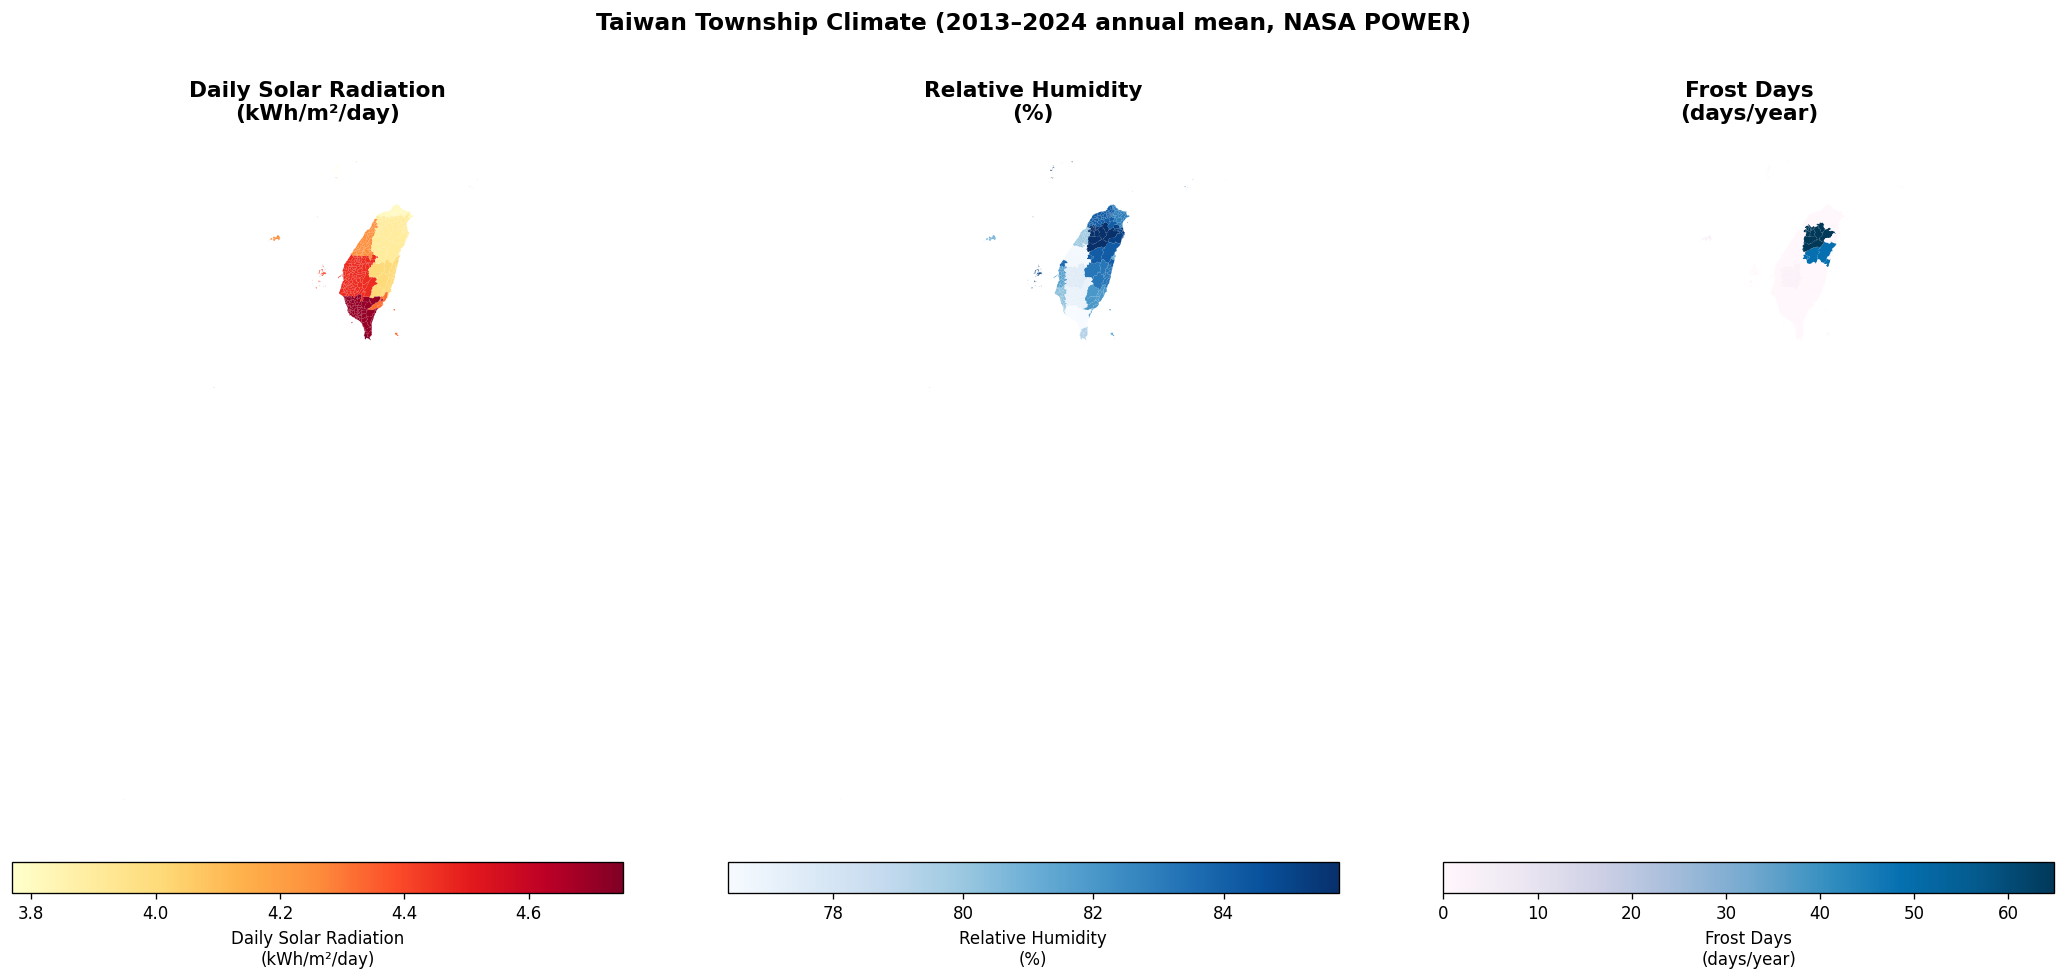

In [44]:
# Merge climate data back to GeoDataFrame for mapping
gdf_map = gdf_dissolved.merge(
    taiwan_climate[['TOWNCODE', 'daily_solar_radiation', 'relative_humidity', 'frost_days']],
    on='TOWNCODE', how='left'
)

fig, axes = plt.subplots(1, 3, figsize=(18, 8))

plot_params = [
    ('daily_solar_radiation', 'Daily Solar Radiation\n(kWh/m²/day)', 'YlOrRd'),
    ('relative_humidity',     'Relative Humidity\n(%)',              'Blues'),
    ('frost_days',            'Frost Days\n(days/year)',             'PuBu'),
]

for ax, (col, title, cmap) in zip(axes, plot_params):
    gdf_map.plot(column=col, ax=ax, cmap=cmap, legend=True,
                 legend_kwds={'label': title, 'orientation': 'horizontal', 'fraction': 0.04, 'pad': 0.04},
                 missing_kwds={'color': 'lightgrey', 'label': 'No data'})
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_axis_off()

plt.suptitle('Taiwan Township Climate (2013–2024 annual mean, NASA POWER)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/figures/transfer/04a_taiwan_climate_choropleth.png',
            dpi=300, bbox_inches='tight')
plt.show()

### 7e. Temporal Stability — Annual Trend for Taipei vs Kaohsiung

C:\Users\a0903\AppData\Local\Temp\ipykernel_34192\1769311598.py:28: UserWarning: Glyph 21488 (\N{CJK UNIFIED IDEOGRAPH-53F0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\a0903\AppData\Local\Temp\ipykernel_34192\1769311598.py:28: UserWarning: Glyph 21271 (\N{CJK UNIFIED IDEOGRAPH-5317}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\a0903\AppData\Local\Temp\ipykernel_34192\1769311598.py:28: UserWarning: Glyph 24066 (\N{CJK UNIFIED IDEOGRAPH-5E02}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\a0903\AppData\Local\Temp\ipykernel_34192\1769311598.py:28: UserWarning: Glyph 22823 (\N{CJK UNIFIED IDEOGRAPH-5927}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\a0903\AppData\Local\Temp\ipykernel_34192\1769311598.py:28: UserWarning: Glyph 23433 (\N{CJK UNIFIED IDEOGRAPH-5B89}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\a0903\AppData\Local\Temp\ipykernel_34192\1769311598.py:28: UserWarning: Glyph 21312 (\

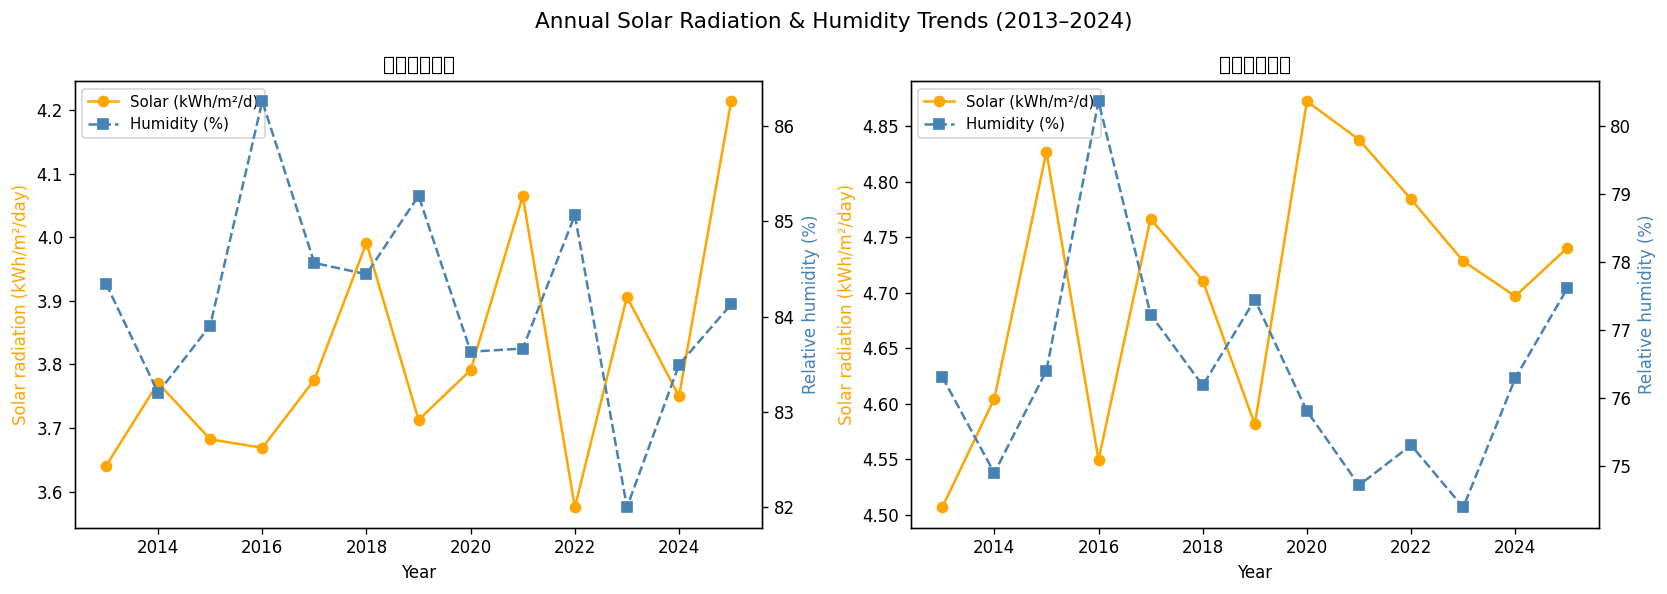

In [45]:
# Pick representative townships: 台北市大安區 and 高雄市鳳山區
# (adjust TOWNCODE if needed)
spot_towns = {
    '台北市大安區':  townships.loc[townships['TOWNNAME'] == '大安區', 'TOWNCODE'].values,
    '高雄市鳳山區':  townships.loc[townships['TOWNNAME'] == '鳳山區', 'TOWNCODE'].values,
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for (label, codes), ax in zip(spot_towns.items(), axes):
    if len(codes) == 0:
        ax.set_title(f'{label} — not found')
        continue
    code = codes[0]
    df_spot = df_annual[df_annual['TOWNCODE'] == code].sort_values('year')
    ax.plot(df_spot['year'], df_spot['daily_solar_radiation'], marker='o', label='Solar (kWh/m²/d)', color='orange')
    ax2 = ax.twinx()
    ax2.plot(df_spot['year'], df_spot['relative_humidity'], marker='s', linestyle='--', label='Humidity (%)', color='steelblue')
    ax.set_xlabel('Year')
    ax.set_ylabel('Solar radiation (kWh/m²/day)', color='orange')
    ax2.set_ylabel('Relative humidity (%)', color='steelblue')
    ax.set_title(label)
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

plt.suptitle('Annual Solar Radiation & Humidity Trends (2013–2024)', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/figures/transfer/04a_taiwan_climate_trend.png',
            dpi=300, bbox_inches='tight')
plt.show()

## Step 8 — Summary

Output files produced:

In [ ]:
print('=== Collection Summary ===')
print(f'Townships collected : {taiwan_climate.TOWNCODE.nunique()} / {len(townships)}')
print(f'Years covered       : {START_YEAR}–{END_YEAR}')
print(f'Climate columns     : {len(climate_cols)}')
print()
print('Output files:')
for p in [RAW_PATH, ANNUAL_PATH, BYYEAR_PATH]:
    size = p.stat().st_size / 1024
    print(f'  {p}  ({size:.0f} KB)')
print()
print('Column mapping to DeepSolar:')
mapping = {
    'daily_solar_radiation':        'ALLSKY_SFC_SW_DWN — annual mean (kWh/m²/day)',
    'relative_humidity':            'RH2M — annual weighted mean (%)',
    'air_temperature':              'T2M — annual weighted mean (°C)',
    'earth_temperature':            'TS — annual weighted mean (°C)',
    'earth_temperature_amplitude':  'TS — max(monthly) − min(monthly) (°C)',
    'wind_speed':                   'WS10M — annual weighted mean (m/s)',
    'atmospheric_pressure':         'PS — annual weighted mean (kPa)',
    'heating_degree_days':          'T2M — Σ max(0, 18.3−T)×days',
    'cooling_degree_days':          'T2M — Σ max(0, T−18.3)×days',
    'heating_design_temperature':   'T2M_MIN — mean of coldest 3 months',
    'cooling_design_temperature':   'T2M_MAX — mean of hottest 3 months',
    'frost_days':                   'T2M_MIN < 2°C proxy (Taiwan-adjusted threshold)',
}
for col, src in mapping.items():
    print(f'  {col:<35} ← {src}')

=== Collection Summary ===
Townships collected : 368 / 368
Years covered       : 2013–2025
Climate columns     : 12

Output files:
  ..\data\taiwan\climate\nasa_power_monthly_raw.parquet  (252 KB)
  ..\data\taiwan\climate\taiwan_climate_annual.csv  (97 KB)
  ..\data\taiwan\climate\taiwan_climate_by_year.csv  (1031 KB)

Column mapping to DeepSolar:
  daily_solar_radiation               ← ALLSKY_SFC_SW_DWN — annual mean (kWh/m²/day)
  relative_humidity                   ← RH2M — annual weighted mean (%)
  air_temperature                     ← T2M — annual weighted mean (°C)
  earth_temperature                   ← TS — annual weighted mean (°C)
  earth_temperature_amplitude         ← TS — max(monthly) − min(monthly) (°C)
  wind_speed                          ← WS10M — annual weighted mean (m/s)
  atmospheric_pressure                ← PS — annual weighted mean (kPa)
  heating_degree_days                 ← T2M — Σ max(0, 18.3−T)×days
  cooling_degree_days                 ← T2M — Σ max(0, T−

: 